# MA429 Summative Project (Section 7)

- **Input Datasets**: "divvy_cleaned.parquet" (trip-level) and "station_hour_features.parquet" (station-hour panel)
- **Final Output**: Demand (Inflow/Outflow) prediction result
- **Section 7 (GAT-LSTM)**: Two-layer **GAT** + Two-layer **LSTM**. Directed graph is built from trip data (start_station_id → end_station_id), sparsified for efficiency. Features and targets from the station-hour panel; temporal split and metrics (MAE, RMSE, WAPE, R²) match Section 5/6.

---
## 7 Demand Forecasting: GAT-LSTM

### 7.0 Imports and load both datasets

Set `SOURCE = "drive"` on Colab or `SOURCE = "local"` locally.

In [1]:
import os
os.environ.setdefault('PYTORCH_ALLOC_CONF', 'expandable_segments:True')
import numpy as np
import pandas as pd
import json
from datetime import datetime
from typing import Dict, List, Optional, Tuple, Any
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt

# Mount Google Drive (Colab)
try:
    from google.colab import drive
    drive.mount("/content/drive")
except ImportError:
    pass

Mounted at /content/drive


In [2]:
SOURCE = "drive"  # "drive" on Colab, "local" locally

if SOURCE == "drive":
    divvy_path = "/content/drive/MyDrive/divvy_cleaned.parquet"
    station_hour_path = "/content/drive/MyDrive/station_hour_features.parquet"
else:
    divvy_path = "divvy_cleaned.parquet"
    station_hour_path = "station_hour_features.parquet"

# Load trip-level data (for building directed graph)
trips_df = pd.read_parquet(divvy_path)
print("divvy_cleaned.parquet shape:", trips_df.shape)
print("Trip columns (relevant):", [c for c in trips_df.columns if "station" in c.lower()])

# Load station-hour panel
df_panel = pd.read_parquet(station_hour_path)
print("station_hour_features.parquet shape (full):", df_panel.shape)

# Use first 30% of time span (same as Section 6)
_df_time = df_panel.sort_values(["date", "hour"]).reset_index(drop=True)
uniq_time = _df_time[["date", "hour"]].drop_duplicates().sort_values(["date", "hour"]).reset_index(drop=True)
T_total = len(uniq_time)
cutoff_T = max(1, int(T_total * 0.30))
uniq_time["_time_idx"] = range(T_total)
_df_time = _df_time.merge(uniq_time, on=["date", "hour"], how="left")
_df_time = _df_time[_df_time["_time_idx"] < cutoff_T].drop(columns=["_time_idx"]).reset_index(drop=True)
df_panel = _df_time
print("Using first 30%% of time steps: %d/%d" % (cutoff_T, T_total))
print("Subsampled date range: %s to %s" % (df_panel["date"].min(), df_panel["date"].max()))
print("Panel shape (time-subsampled 30%%):", df_panel.shape)

divvy_cleaned.parquet shape: (6236970, 18)
Trip columns (relevant): ['start_station_name', 'start_station_id', 'end_station_name', 'end_station_id']
station_hour_features.parquet shape (full): (21132864, 53)
Using first 30% of time steps: 3283/10944
Subsampled date range: 2024-01-01 to 2024-05-16
Panel shape (time-subsampled 30%%): (6339473, 53)


### 7.1 Build directed graph from trip data and sparsify

From **divvy_cleaned.parquet**, build directed arcs: each trip gives an edge from `start_station_id` to `end_station_id`. Aggregate edge counts, then **sparsify** by keeping **top-k in-edges and top-k out-edges per node** (by count), so each node retains both "who sends to me" and "where I send" structure. Restrict nodes to stations present in the panel.

In [3]:
# Stations that appear in the (time-subsampled) panel
panel_stations = set(df_panel["station_id"].astype(str).str.strip().unique())
# Filter trips: both endpoints must be valid
trips_clean = trips_df.dropna(subset=["start_station_id", "end_station_id"]).copy()
trips_clean["start_station_id"] = trips_clean["start_station_id"].astype(str).str.strip()
trips_clean["end_station_id"] = trips_clean["end_station_id"].astype(str).str.strip()
trips_clean = trips_clean[
    trips_clean["start_station_id"].str.lower() != "unknown"
].copy()
trips_clean = trips_clean[
    trips_clean["end_station_id"].str.lower() != "unknown"
].copy()
trips_clean = trips_clean[
    trips_clean["start_station_id"].isin(panel_stations)
    & trips_clean["end_station_id"].isin(panel_stations)
].copy()

train_end_date = df_panel["date"].sort_values().unique()[int(len(df_panel["date"].unique()) * 0.70)]
trips_clean = trips_clean[trips_clean["started_at"].dt.date.astype(str) < str(train_end_date)]

# Directed edge counts: (from_station, to_station) -> count
edge_counts = (
    trips_clean.groupby(["start_station_id", "end_station_id"])
    .size()
    .reset_index(name="count")
)
print("Unique directed edges (before sparsify):", len(edge_counts))

# Sparsify: keep top TOP_K in-edges and top TOP_K out-edges per node (by count)
TOP_K_EDGES = 50  # max in-edges and max out-edges per node after sparsification
edge_counts_sorted = edge_counts.sort_values("count", ascending=False)
sparse_in = []
for to_station, grp in edge_counts_sorted.groupby("end_station_id"):
    sparse_in.append(grp.head(TOP_K_EDGES))
in_edges = pd.concat(sparse_in, ignore_index=True)
sparse_out = []
for from_station, grp in edge_counts_sorted.groupby("start_station_id"):
    sparse_out.append(grp.head(TOP_K_EDGES))
out_edges = pd.concat(sparse_out, ignore_index=True)
edge_counts = pd.concat([in_edges, out_edges], ignore_index=True).drop_duplicates(subset=["start_station_id", "end_station_id"])
print("Unique directed edges (after sparsify, top-%d in + top-%d out per node):" % (TOP_K_EDGES, TOP_K_EDGES), len(edge_counts))

# Station index: consistent ordering with panel
station_order = sorted(panel_stations)
station_to_idx = {s: i for i, s in enumerate(station_order)}
N = len(station_order)

# COO edge_index: (2, E) with indices in [0, N-1]; row0 = source, row1 = target
edge_index = np.array([
    edge_counts["start_station_id"].map(station_to_idx).values,
    edge_counts["end_station_id"].map(station_to_idx).values,
], dtype=np.int64)
# Remove any edge that didn't map (safety)
valid = (edge_index[0] >= 0) & (edge_index[0] < N) & (edge_index[1] >= 0) & (edge_index[1] < N)
edge_index = edge_index[:, valid]
# Add self-loops so every node attends to itself during GAT aggregation
self_loop_src = np.arange(N, dtype=np.int64)
self_loop_idx = np.stack([self_loop_src, self_loop_src], axis=0)  # (2, N)
edge_index = np.concatenate([edge_index, self_loop_idx], axis=1)
print("Edge index with self-loops:", edge_index.shape)
# Deduplicate edges (self-loops may overlap with existing edges)
edge_index = np.unique(edge_index, axis=1)
print("Bidirectional edge index:", edge_index.shape)
print("Graph: N = %d nodes, E = %d edges" % (N, edge_index.shape[1]))
# Align log1p(trip count) to each edge; synthetic edges get 0
count_lookup = edge_counts.set_index(["start_station_id", "end_station_id"])["count"].to_dict()
station_order_arr = np.array(station_order)
edge_counts_arr = np.array([
    count_lookup.get(
        (station_order_arr[edge_index[0, i]], station_order_arr[edge_index[1, i]]), 0
    )
    for i in range(edge_index.shape[1])
], dtype=np.float32)
edge_feats = np.log1p(edge_counts_arr).reshape(-1, 1)  # (E, 1)
edge_feat_dim = edge_feats.shape[1]
print("edge_feats shape:", edge_feats.shape)

Unique directed edges (before sparsify): 73554
Unique directed edges (after sparsify, top-50 in + top-50 out per node): 38148
Edge index with self-loops: (2, 40078)
Bidirectional edge index: (2, 39251)
Graph: N = 1930 nodes, E = 39251 edges
edge_feats shape: (39251, 1)


### 7.2 Config and feature set

Single-step targets, full feature set A (base + heterogeneity), temporal split 70% / 15% / 15%, sequence length, and GAT+LSTM hyperparameters.

In [4]:
DEFAULT_TARGETS = ["target_outflow_t1", "target_inflow_t1"]
RUN_FEATURE_SET = "base_all_heterogeneity"
SPLIT_TRAIN_RATIO = 0.70
SPLIT_VAL_RATIO = 0.15
SPLIT_TEST_RATIO = 0.15
assert abs(SPLIT_TRAIN_RATIO + SPLIT_VAL_RATIO + SPLIT_TEST_RATIO - 1.0) < 1e-9

BASE_FLOW = ["outflow", "inflow"]
BASE_TIME = ["hour", "day_of_week", "is_weekend", "month", "sin_hour", "cos_hour"]
BASE_STATION = ["lat", "lng", "historical_mean_outflow", "historical_mean_inflow"]
HETEROGENEITY_MEMBER_CASUAL = ["member_ratio", "casual_ratio"]
HETEROGENEITY_CLUSTER = [f"cluster_{i}_ratio" for i in range(9)]
HETEROGENEITY_ALL = HETEROGENEITY_MEMBER_CASUAL + HETEROGENEITY_CLUSTER

def get_feature_columns(all_columns: List[str]) -> List[str]:
    base = [c for c in (BASE_FLOW + BASE_TIME + BASE_STATION + HETEROGENEITY_ALL) if c in all_columns]
    return base

DEFAULT_SEQ_LEN = 24
DEFAULT_GAT_LSTM_CONFIG = {
    "gat_heads": 4,
    "gat_hidden": 64,  
    "lstm_hidden": 64,
    "lstm_layers": 2,
    "dropout": 0.2,
    "epochs": 50,
    "times_per_batch": 8,
    "learning_rate": 0.001,
    "early_stopping_patience": 15,
}

if "SOURCE" in dir() and SOURCE == "drive":
    RESULTS_DIR = "/content/drive/MyDrive/section7_results"
else:
    RESULTS_DIR = "section7_results"
os.makedirs(RESULTS_DIR, exist_ok=True)
LOG_DIR = os.path.join(RESULTS_DIR, "logs")
CONFIG_DIR = os.path.join(RESULTS_DIR, "configs")
os.makedirs(LOG_DIR, exist_ok=True)
os.makedirs(CONFIG_DIR, exist_ok=True)

### 7.3 Temporal split and evaluation metrics

Same as Section 5/6: split by time (no shuffle); MAE, RMSE, WAPE, R².

In [5]:
def temporal_train_val_test_split(
    df: pd.DataFrame,
    train_ratio: float = SPLIT_TRAIN_RATIO,
    val_ratio: float = SPLIT_VAL_RATIO,
    test_ratio: float = SPLIT_TEST_RATIO,
) -> Tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    assert abs(train_ratio + val_ratio + test_ratio - 1.0) < 1e-9
    n = len(df)
    n_train = int(n * train_ratio)
    n_val = int(n * val_ratio)
    train_df = df.iloc[:n_train]
    val_df = df.iloc[n_train : n_train + n_val]
    test_df = df.iloc[n_train + n_val :]
    return train_df, val_df, test_df

def mae(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    return float(np.mean(np.abs(y_true - y_pred)))
def rmse(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    return float(np.sqrt(np.mean((y_true - y_pred) ** 2)))
def wape(y_true: np.ndarray, y_pred: np.ndarray, eps: float = 1e-8) -> float:
    s_abs_diff = np.sum(np.abs(y_true - y_pred))
    s_abs_true = np.sum(np.abs(y_true)) + eps
    return float(s_abs_diff / s_abs_true)
def r2(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    if ss_tot < 1e-12:
        return 0.0
    return float(1.0 - ss_res / ss_tot)

def compute_metrics(y_true: np.ndarray, y_pred: np.ndarray) -> Dict[str, float]:
    return {"MAE": mae(y_true, y_pred), "RMSE": rmse(y_true, y_pred), "WAPE": wape(y_true, y_pred), "R2": r2(y_true, y_pred)}

def append_result(results_list: List[Dict], model_name: str, target: str, feature_set: str, split: str, metrics: Dict[str, float], extra: Optional[Dict] = None) -> None:
    row = {"model": model_name, "target": target, "feature_set": feature_set, "split": split, **metrics}
    if extra:
        row.update(extra)
    results_list.append(row)

### 7.4 Build (T, N, F) panel and time splits

Reshape the station-hour panel into a 3D array: for each time index we have (N, F). Align by (date, hour) and station_id using the same `station_order` as the graph.

In [6]:
feature_cols = get_feature_columns(list(df_panel.columns))
# Ensure we have target columns
for t in DEFAULT_TARGETS:
    if t not in df_panel.columns:
        raise KeyError("Panel missing target column: %s" % t)

# Build time index (date, hour) -> _time_idx 
df_panel = df_panel.sort_values(["date", "hour", "station_id"]).reset_index(drop=True)
uniq_time_panel = df_panel[["date", "hour"]].drop_duplicates().sort_values(["date", "hour"]).reset_index(drop=True)
T_panel = len(uniq_time_panel)
uniq_time_panel["_time_idx"] = np.arange(T_panel, dtype=np.int64)
df_panel = df_panel.merge(uniq_time_panel, on=["date", "hour"], how="left")

# Build station index (station_id -> _station_idx) 
_station_idx = df_panel["station_id"].astype(str).str.strip().map(station_to_idx)
_df_idxed = df_panel.assign(_station_idx=_station_idx)
_df_idxed = _df_idxed.dropna(subset=["_station_idx", "_time_idx"]).copy()
_df_idxed["_station_idx"] = _df_idxed["_station_idx"].astype(np.int64)
_df_idxed["_time_idx"] = _df_idxed["_time_idx"].astype(np.int64)

# Safety: ensure unique (time_idx, station_idx) pairs
_dups = _df_idxed.duplicated(subset=["_time_idx", "_station_idx"], keep=False)
if _dups.any():
    # If duplicates exist, keep last (should not happen in a well-formed panel)
    _df_idxed = _df_idxed.sort_values(["_time_idx", "_station_idx"]).drop_duplicates(subset=["_time_idx", "_station_idx"], keep="last")

# Allocate and fill X_panel_3d in one shot using integer indexing
n_features = len(feature_cols)
X_panel_3d = np.zeros((T_panel, N, n_features), dtype=np.float32)

ti = _df_idxed["_time_idx"].to_numpy(dtype=np.int64)
si = _df_idxed["_station_idx"].to_numpy(dtype=np.int64)
feat_vals = _df_idxed[feature_cols].to_numpy(dtype=np.float32, copy=False)
X_panel_3d[ti, si, :] = feat_vals
# Z-score normalise X_panel_3d using training-set statistics only (targets unchanged for comparable MAE/RMSE/WAPE/R²)
t_train_idx = int(T_panel * SPLIT_TRAIN_RATIO)
train_mean = X_panel_3d[:t_train_idx].mean(axis=(0, 1), keepdims=True)  # shape (1, 1, F)
train_std  = X_panel_3d[:t_train_idx].std(axis=(0, 1),  keepdims=True) + 1e-8
X_panel_3d = (X_panel_3d - train_mean) / train_std
print("X_panel_3d normalised — train mean≈0, std≈1")

print("Panel 3D shape (T, N, F):", X_panel_3d.shape)

# Target arrays (T, N) for each target
target_arrays = {}
for tcol in DEFAULT_TARGETS:
    arr = np.zeros((T_panel, N), dtype=np.float32)
    y = _df_idxed[tcol].to_numpy(dtype=np.float32, copy=False)
    arr[ti, si] = np.nan_to_num(y, nan=0.0, posinf=0.0, neginf=0.0)
    target_arrays[tcol] = arr

X_panel_3d normalised — train mean≈0, std≈1
Panel 3D shape (T, N, F): (3283, 1930, 23)


### 7.5  GAT-LSTM model

**GAT**: two layers of graph attention. **Pre-Norm** + **residual** per layer: `h1 = GAT1(x_t) + Linear(x_t)`, `h_t = GAT2(h1) + Linear(h1)`; before LSTM, `LayerNorm` on the sequence; readout `last = LSTM_out + Linear(last_frame)`. **GAT+LSTM**: (N, F) per step → GAT1+skip → GAT2+skip → LSTM+skip → linear scalar per node.

In [ ]:
class GATLayer(nn.Module):
    def __init__(self, in_dim, out_dim, n_heads=4, dropout=0.0, edge_feat_dim=0):
        super().__init__()
        self.n_heads = n_heads
        self.head_dim = out_dim // n_heads
        assert self.head_dim * n_heads == out_dim
        self.norm_in = nn.LayerNorm(in_dim)
        self.W = nn.Linear(in_dim, out_dim, bias=False)
        self.a = nn.Parameter(torch.empty(n_heads, 2 * self.head_dim))
        self.leaky = nn.LeakyReLU(0.2)
        self.dropout = nn.Dropout(dropout)
        nn.init.xavier_uniform_(self.a)
        # per-head bias from edge features (trip strength etc.)
        self.use_edge_feats = edge_feat_dim > 0
        if self.use_edge_feats:
            self.W_edge = nn.Linear(edge_feat_dim, n_heads, bias=True)

    def forward(self, x, edge_index, edge_feats=None):
        # x: (N, in_dim)  edge_index: (2, E)  edge_feats: (E, edge_feat_dim) or None
        N = x.size(0)
        src, tgt = edge_index[0], edge_index[1]

        x = self.norm_in(x)
        h = self.W(x).view(N, self.n_heads, self.head_dim)
        h_src = h[src]
        h_tgt = h[tgt]

        e = self.leaky(
            (torch.cat([h_tgt, h_src], dim=-1) * self.a.unsqueeze(0)).sum(-1)
        )  # (E, H)
        if self.use_edge_feats and edge_feats is not None:
            e = e + self.W_edge(edge_feats)  # bias attention by edge attributes

        e_max = torch.full((N, self.n_heads), float("-inf"), device=x.device, dtype=e.dtype)
        idx = tgt.unsqueeze(1).expand(-1, self.n_heads)
        e_max.scatter_reduce_(0, idx, e, reduce="amax", include_self=True)
        e = e - e_max[tgt]
        exp_e = torch.exp(e)
        denom = torch.zeros(N, self.n_heads, device=x.device)
        denom.index_add_(0, tgt, exp_e)
        alpha = self.dropout(exp_e / (denom[tgt] + 1e-16))

        out = torch.zeros(N, self.n_heads, self.head_dim, device=x.device)
        contrib = alpha.unsqueeze(-1) * h_src
        out.index_add_(0, tgt, contrib)
        return out.view(N, -1)

In [ ]:
class GAT_LSTM_Model(nn.Module):
    """Two-layer GAT + LSTM; edge-aware GAT + temporal attention readout."""
    def __init__(self, in_dim: int, gat_hidden: int, gat_heads: int, lstm_hidden: int, lstm_layers: int, dropout: float, edge_feat_dim: int = 0):
        super().__init__()
        self.gat1 = GATLayer(in_dim, gat_hidden, n_heads=gat_heads, dropout=dropout, edge_feat_dim=edge_feat_dim)
        self.res_gat1 = nn.Linear(in_dim, gat_hidden)
        self.gat2 = GATLayer(gat_hidden, gat_hidden, n_heads=gat_heads, dropout=dropout, edge_feat_dim=edge_feat_dim)
        self.res_gat2 = nn.Linear(gat_hidden, gat_hidden)
        self.norm_pre_lstm = nn.LayerNorm(gat_hidden)
        self.lstm = nn.LSTM(gat_hidden, lstm_hidden, lstm_layers, batch_first=True,
                            dropout=dropout if lstm_layers > 1 else 0)
        self.res_lstm = nn.Linear(gat_hidden, lstm_hidden)
        # learn which timesteps in the window matter for prediction
        self.temporal_attn = nn.Linear(lstm_hidden, 1)
        self.fc = nn.Linear(lstm_hidden, 1)

    def forward(self, x: torch.Tensor, edge_index: torch.Tensor, edge_feats=None):
        # Per-step GAT keeps memory low and matches one (E,) edge feature row per message
        seq_len, N, _ = x.size()
        h_list = []
        for t in range(seq_len):
            xt = x[t]
            h1 = self.gat1(xt, edge_index, edge_feats) + self.res_gat1(xt)
            h_t = self.gat2(h1, edge_index, edge_feats) + self.res_gat2(h1)
            h_list.append(h_t)
        h_stack = torch.stack(h_list, dim=1)  # (N, seq_len, gat_hidden)
        h_in = self.norm_pre_lstm(h_stack)
        out, _ = self.lstm(h_in)  # (N, seq_len, lstm_hidden)
        attn_scores = torch.softmax(self.temporal_attn(out), dim=1)
        last = (attn_scores * out).sum(dim=1)
        last = last + self.res_lstm(h_in[:, -1, :])
        return self.fc(last).squeeze(-1)

### 7.6 Training loop

 **Full-graph training with time-only mini-batch**: shuffle train time indices each epoch; chunk into batches of size `times_per_batch`. For each batch, for every time step t we use input (seq_len, N, F) and run the model once; loss is computed on full graph. One gradient update per batch (average loss over the time steps in the batch). Validation and test run over all time steps and all nodes (same metrics as Section 5/6).

In [9]:
seq_len = DEFAULT_SEQ_LEN
t_train = int(T_panel * SPLIT_TRAIN_RATIO)
t_val = int(T_panel * SPLIT_VAL_RATIO)
t_test = T_panel - t_train - t_val
train_times = [t for t in range(seq_len, t_train)]
val_times = [t for t in range(t_train, t_train + t_val) if t >= seq_len]
test_times = [t for t in range(t_train + t_val, T_panel) if t >= seq_len]
edge_index_t = torch.from_numpy(edge_index).long()
edge_feats_t = torch.from_numpy(edge_feats).float()  # CPU; train_gat_lstm moves to device

def _get_device():
    if torch.cuda.is_available():
        return torch.device("cuda")
    if getattr(torch.backends, "mps", None) is not None and torch.backends.mps.is_available():
        return torch.device("mps")
    return torch.device("cpu")

def train_gat_lstm(
    X_panel_3d: np.ndarray,
    target_arr: np.ndarray,
    edge_feats: np.ndarray,
    edge_index: np.ndarray,
    train_times: List[int],
    val_times: List[int],
    test_times: List[int],
    seq_len: int,
    feature_dim: int,
    config: Optional[Dict] = None,
    log_callback: Optional[Any] = None,
) -> Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray, nn.Module, Optional[Dict]]:
    cfg = dict(DEFAULT_GAT_LSTM_CONFIG)
    if config:
        cfg.update(config)
    device = _get_device()
    model = GAT_LSTM_Model(
        in_dim=feature_dim,
        gat_hidden=cfg["gat_hidden"],
        gat_heads=cfg["gat_heads"],
        lstm_hidden=cfg["lstm_hidden"],
        lstm_layers=cfg["lstm_layers"],
        dropout=cfg["dropout"],
        edge_feat_dim=edge_feats.shape[1],
    ).to(device)
    edge_index_t = torch.from_numpy(edge_index).long().to(device)
    edge_feats_t = torch.from_numpy(edge_feats).float().to(device)
    # Pre-pin full arrays to page-locked memory for fast async H2D transfer 
    try:
        X_pt = torch.from_numpy(X_panel_3d).float().pin_memory()
        y_pt = torch.from_numpy(target_arr).float().pin_memory()
    except Exception:
        X_pt = torch.from_numpy(X_panel_3d).float()
        y_pt = torch.from_numpy(target_arr).float()
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=cfg["learning_rate"])
    patience = cfg.get("early_stopping_patience", 10)
    best_val_rmse = float("inf")
    best_state = None
    epochs_no_improve = 0
    history = {"train_loss": [], "val_loss": [], "val_rmse": [], "val_r2": []}

    times_per_batch = cfg.get("times_per_batch", 32)
    rng = np.random.default_rng()
    for ep in range(cfg["epochs"]):
        model.train()
        total_loss = 0.0
        n_batches = 0
        train_times_shuffled = list(train_times)
        rng.shuffle(train_times_shuffled)
        for start in range(0, len(train_times_shuffled), times_per_batch):
            batch_times = train_times_shuffled[start : start + times_per_batch]
            if not batch_times:
                continue
            optimizer.zero_grad()
            batch_loss_sum = 0.0
            for t in batch_times:
                X_b = X_pt[t - seq_len : t].to(device, non_blocking=True)
                y_b = y_pt[t].to(device, non_blocking=True)
                pred = model(X_b, edge_index_t, edge_feats_t)
                loss_t = criterion(pred, y_b) / len(batch_times)  # scale before backward
                loss_t.backward()  # frees this step's graph immediately
                batch_loss_sum += loss_t.item() * len(batch_times)
            optimizer.step()
            torch.cuda.empty_cache()  # release fragment allocations between batches
            total_loss += batch_loss_sum / len(batch_times)
            n_batches += 1
        avg_loss = total_loss / max(n_batches, 1)
        model.eval()
        torch.cuda.empty_cache()  # clear training graph memory before running validation
        val_preds = []
        val_gt = []
        with torch.no_grad():
            for t in val_times:
                X_b = X_pt[t - seq_len : t].to(device, non_blocking=True)
                val_preds.append(model(X_b, edge_index_t, edge_feats_t).cpu().numpy())
                val_gt.append(target_arr[t])
        val_pred = np.concatenate(val_preds, axis=0) if val_preds else np.zeros(0, dtype=np.float32)
        val_gt = np.concatenate(val_gt, axis=0) if val_gt else np.zeros(0, dtype=np.float32)
        val_rmse_i = rmse(val_gt, val_pred) if len(val_gt) > 0 else float("inf")
        val_r2_i = r2(val_gt, val_pred) if len(val_gt) > 0 else 0.0
        val_loss_i = float(np.mean((val_gt - val_pred) ** 2)) if len(val_gt) > 0 else float("inf")
        history["train_loss"].append(avg_loss)
        history["val_loss"].append(val_loss_i)
        history["val_rmse"].append(val_rmse_i)
        history["val_r2"].append(val_r2_i)
        if log_callback:
            log_callback("  Epoch %d/%d  train_loss=%.6f  val_loss=%.6f  val_rmse=%.6f  val_r2=%.4f" % (ep + 1, cfg["epochs"], avg_loss, val_loss_i, val_rmse_i, val_r2_i))
        if val_rmse_i < best_val_rmse:
            best_val_rmse = val_rmse_i
            import copy as _copy
            best_state = _copy.deepcopy(model.state_dict())
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
        if epochs_no_improve >= patience:
            if log_callback:
                log_callback("  Early stopping at epoch %d" % (ep + 1))
            break
    if best_state is not None:
        model.load_state_dict(best_state)
    model.eval()
    torch.cuda.empty_cache()  # clear training graph memory before running validation
    val_preds = []
    val_gt = []
    test_preds = []
    test_gt = []
    with torch.no_grad():
        for t in val_times:
            X_b = X_pt[t - seq_len : t].to(device, non_blocking=True)
            val_preds.append(model(X_b, edge_index_t, edge_feats_t).cpu().numpy())
            val_gt.append(target_arr[t])
        for t in test_times:
            X_b = X_pt[t - seq_len : t].to(device, non_blocking=True)
            test_preds.append(model(X_b, edge_index_t, edge_feats_t).cpu().numpy())
            test_gt.append(target_arr[t])
    vp = np.concatenate(val_preds, axis=0) if val_preds else np.zeros(0, dtype=np.float32)
    vg = np.concatenate(val_gt, axis=0) if val_gt else np.zeros(0, dtype=np.float32)
    tp = np.concatenate(test_preds, axis=0) if test_preds else np.zeros(0, dtype=np.float32)
    tg = np.concatenate(test_gt, axis=0) if test_gt else np.zeros(0, dtype=np.float32)
    return vp, vg, tp, tg, model, history

### 7.7 Run GAT-LSTM and record metrics

Run for both targets (target_outflow_t1, target_inflow_t1), record val/test metrics, and save config and results.

In [10]:
all_results = []
train_log_path = os.path.join(LOG_DIR, "training_iteration_log.txt")
train_log = open(train_log_path, "w")
def log_iter(msg):
    print(msg)
    train_log.write(msg + "\n")
    train_log.flush()
log_iter("Section 7 - GAT+LSTM run started " + datetime.now().isoformat())
test_predictions = {}
histories = {}

for target in DEFAULT_TARGETS:
    log_iter("")
    log_iter("--- target=%s ---" % target)
    val_pred, val_gt, test_pred, test_gt, model, history = train_gat_lstm(
        X_panel_3d,
        target_arrays[target],
        edge_feats,  # log1p trip counts as GAT attention bias per edge
        edge_index,
        train_times,
        val_times,
        test_times,
        seq_len,
        n_features,
        log_callback=log_iter,
    )
    histories[target] = history
    append_result(all_results, "GAT_LSTM", target, RUN_FEATURE_SET, "val", compute_metrics(val_gt, val_pred))
    append_result(all_results, "GAT_LSTM", target, RUN_FEATURE_SET, "test", compute_metrics(test_gt, test_pred))
    # Build test prediction DataFrame: station_id, date, hour, target, pred
    rows = []
    for i, t in enumerate(test_times):
        date, hour = uniq_time_panel.iloc[t]["date"], uniq_time_panel.iloc[t]["hour"]
        for j in range(N):
            rows.append({
                "station_id": station_order[j],
                "date": date,
                "hour": hour,
                target: test_gt[i * N + j],
                "pred": test_pred[i * N + j],
            })
    test_predictions[target] = pd.DataFrame(rows)
train_log.close()

Section 7 - GAT+LSTM run started 2026-03-27T03:56:16.230133

--- target=target_outflow_t1 ---
  Epoch 1/50  train_loss=0.247255  val_loss=0.592450  val_rmse=0.769708  val_r2=0.4255
  Epoch 2/50  train_loss=0.215523  val_loss=0.502310  val_rmse=0.708738  val_r2=0.5129
  Epoch 3/50  train_loss=0.202963  val_loss=0.511950  val_rmse=0.715507  val_r2=0.5036
  Epoch 4/50  train_loss=0.195359  val_loss=0.471161  val_rmse=0.686412  val_r2=0.5431
  Epoch 5/50  train_loss=0.189909  val_loss=0.470845  val_rmse=0.686182  val_r2=0.5434
  Epoch 6/50  train_loss=0.186290  val_loss=0.436517  val_rmse=0.660694  val_r2=0.5767
  Epoch 7/50  train_loss=0.182323  val_loss=0.443794  val_rmse=0.666179  val_r2=0.5697
  Epoch 8/50  train_loss=0.181208  val_loss=0.431819  val_rmse=0.657129  val_r2=0.5813
  Epoch 9/50  train_loss=0.180480  val_loss=0.420059  val_rmse=0.648120  val_r2=0.5927
  Epoch 10/50  train_loss=0.176780  val_loss=0.422875  val_rmse=0.650289  val_r2=0.5899
  Epoch 11/50  train_loss=0.176212 

In [11]:
run_config = {
    "split_ratios": {"train": SPLIT_TRAIN_RATIO, "val": SPLIT_VAL_RATIO, "test": SPLIT_TEST_RATIO},
    "targets": DEFAULT_TARGETS,
    "feature_set": RUN_FEATURE_SET,
    "timestamp": datetime.now().isoformat(),
    "n_nodes": N,
    "n_edges": edge_index.shape[1],
    "seq_len": seq_len,
}
with open(os.path.join(CONFIG_DIR, "run_config.json"), "w") as f:
    json.dump(run_config, f, indent=2)
results_df = pd.DataFrame(all_results)
results_df.to_csv(os.path.join(RESULTS_DIR, "gat_lstm_results.csv"), index=False)
print("Results saved to", RESULTS_DIR)

Results saved to /content/drive/MyDrive/section7_results


### 7.8 Evaluation metrics and visualization

Display the validation and test set evaluation metrics (MAE, RMSE, WAPE, R²), plot GAT+LSTM train loss and validation loss (MSE) vs epoch, and plot total flow (actual vs predicted) for test period by hour.

In [12]:
# --- Full results (validation + test) ---
display(results_df)

,model,target,feature_set,split,MAE,RMSE,WAPE,R2
0,GAT_LSTM,target_outflow_t1,base_all_heterogeneity,val,0.186441,0.616019,0.851790,0.632028
1,GAT_LSTM,target_outflow_t1,base_all_heterogeneity,test,0.219460,0.720881,0.813507,0.629580
2,GAT_LSTM,target_inflow_t1,base_all_heterogeneity,val,0.187026,0.623217,0.854463,0.628735
3,GAT_LSTM,target_inflow_t1,base_all_heterogeneity,test,0.218614,0.733216,0.810371,0.619671


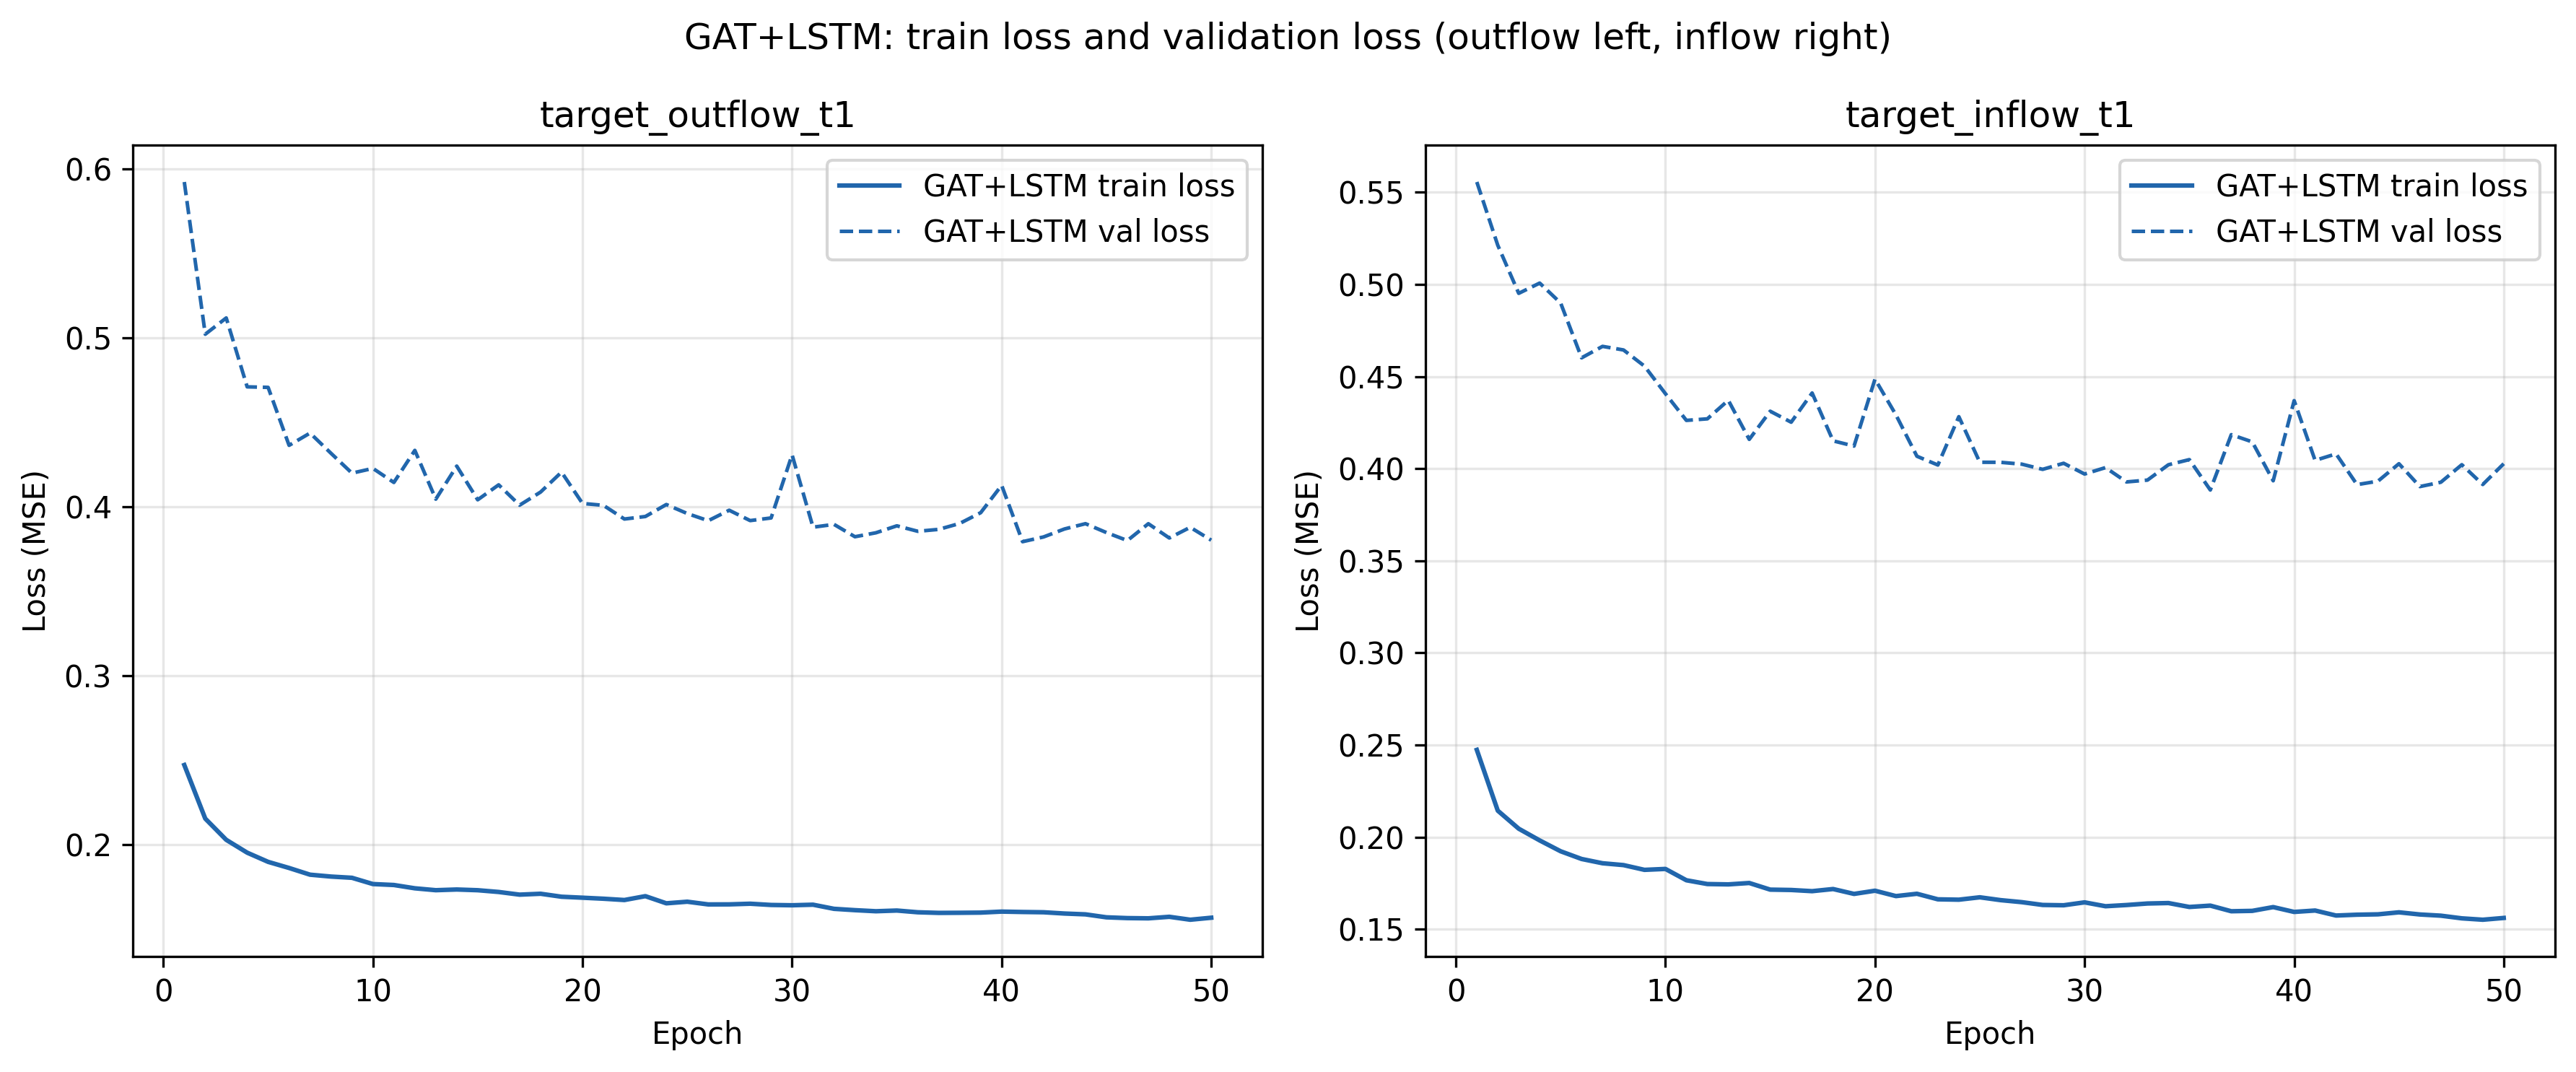

In [13]:
# --- GAT+LSTM: train loss and validation loss vs epoch (outflow left, inflow right) ---
DPI = 300
COLOR_GAT = "#2166AC"
OUTFLOW_T1, INFLOW_T1 = "target_outflow_t1", "target_inflow_t1"
fig, axes = plt.subplots(1, 2, figsize=(12, 5), dpi=DPI)
for col, target in enumerate([OUTFLOW_T1, INFLOW_T1]):
    h = histories.get(target)
    ax = axes[col]
    if h is not None:
        ep = range(1, len(h["train_loss"]) + 1)
        ax.plot(ep, h["train_loss"], color=COLOR_GAT, label="GAT+LSTM train loss", lw=1.5)
        val_loss = h.get("val_loss", [])
        if len(val_loss) == len(ep):
            ax.plot(ep, val_loss, color=COLOR_GAT, linestyle="--", label="GAT+LSTM val loss", lw=1.2)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss (MSE)")
    ax.set_title(target)
    ax.legend()
    ax.grid(True, alpha=0.3)
plt.suptitle("GAT+LSTM: train loss and validation loss (outflow left, inflow right)")
plt.tight_layout()
plt.show()

GAT+LSTM: All stations — total flow by hour (Actual vs Predicted)


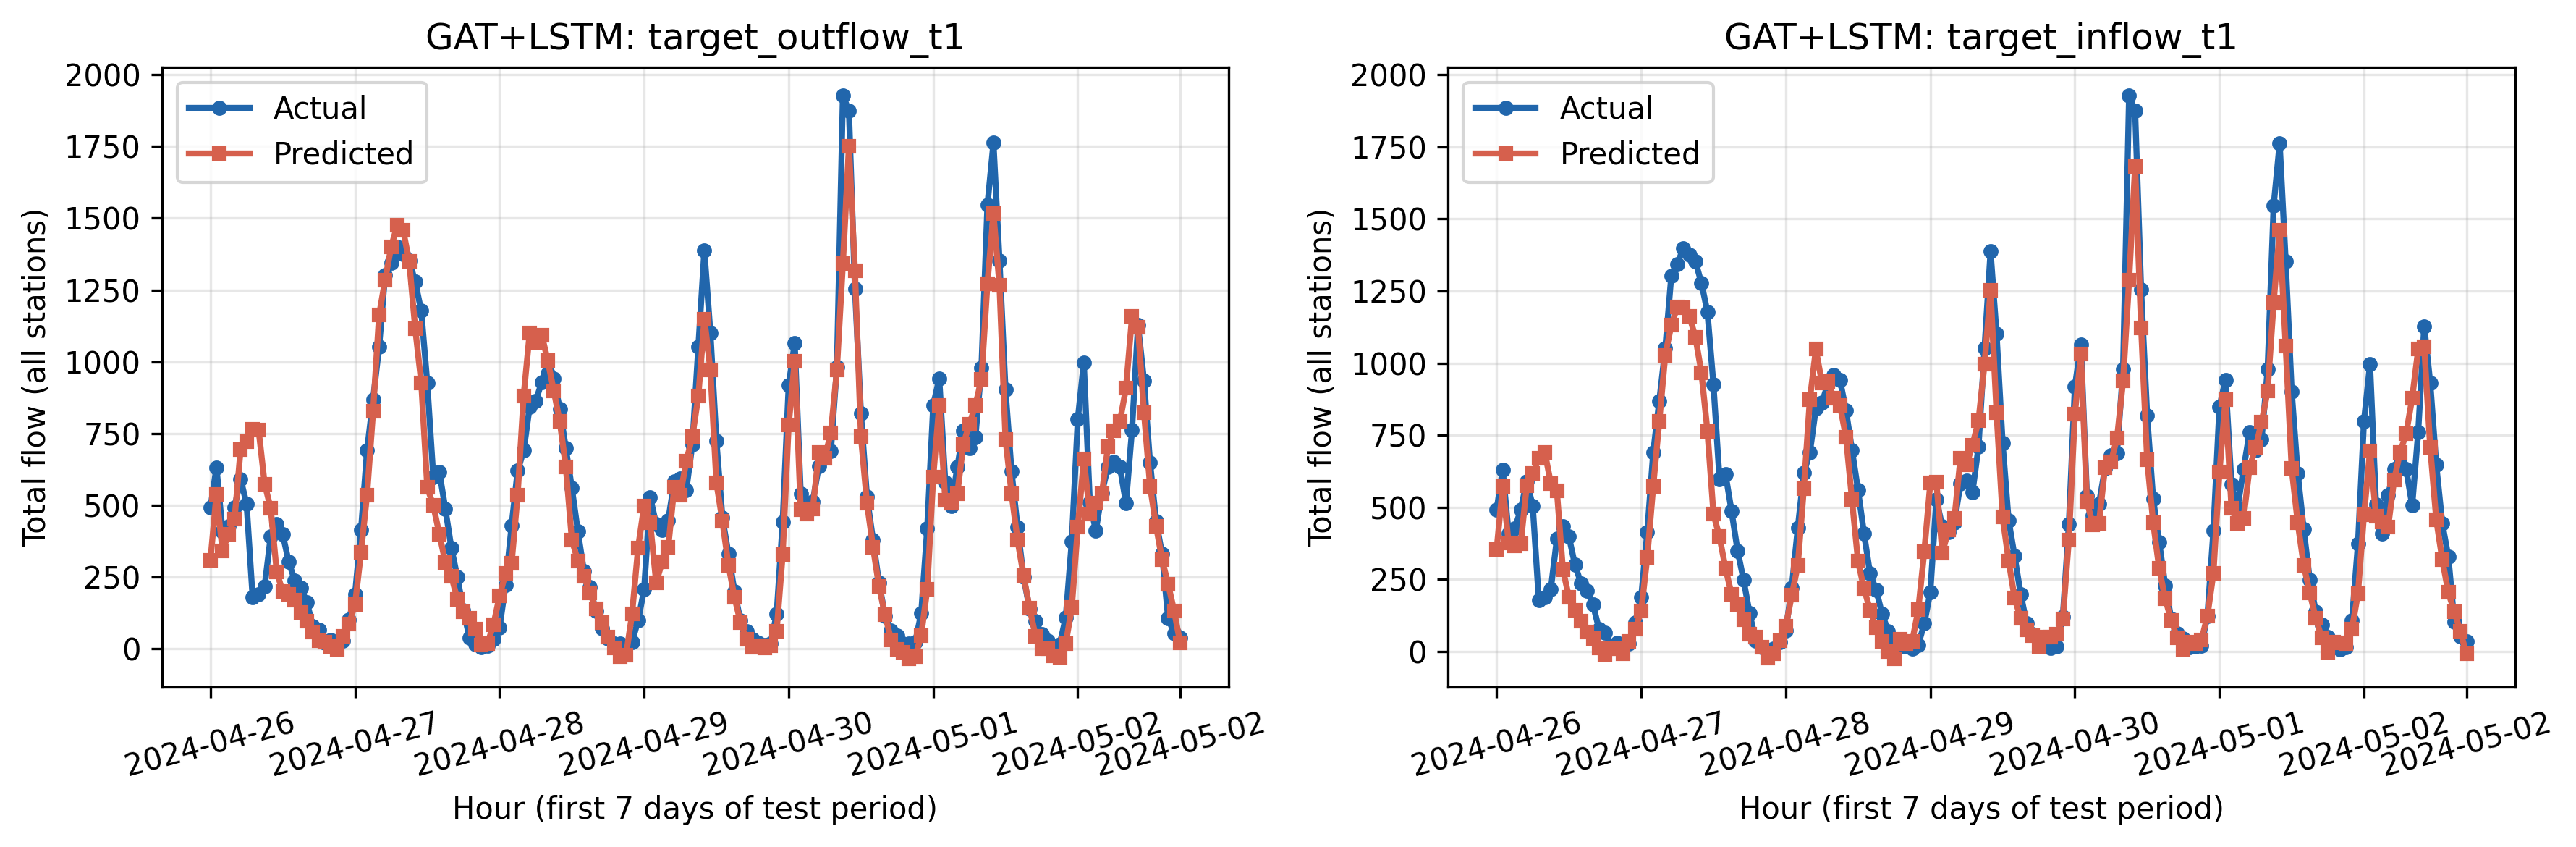

In [14]:
# --- All stations: total flow by hour — Actual vs Predicted ---
OUTFLOW_T1, INFLOW_T1 = "target_outflow_t1", "target_inflow_t1"
TARGETS_ORDER = [OUTFLOW_T1, INFLOW_T1]
COLOR_ACTUAL, COLOR_PRED = "#2166AC", "#D6604D"
print("GAT+LSTM: All stations — total flow by hour (Actual vs Predicted)")
fig, axes = plt.subplots(1, 2, figsize=(12, 4), dpi=300)
for col, target in enumerate(TARGETS_ORDER):
    ax = axes[col]
    if target not in test_predictions:
        ax.set_title(f"GAT+LSTM / {target} (no data)")
        continue
    df_vis = test_predictions[target]
    actual_col = target
    first_3_dates = sorted(df_vis["date"].unique())[:7]
    df_3d = df_vis[df_vis["date"].isin(first_3_dates)]
    hourly = df_3d.groupby(["date", "hour"]).agg(actual=(actual_col, "sum"), pred=("pred", "sum")).reset_index()
    hourly = hourly.sort_values(["date", "hour"]).reset_index(drop=True)
    x = np.arange(len(hourly))
    ax.plot(x, hourly["actual"], color=COLOR_ACTUAL, label="Actual", lw=2, marker="o", markersize=4)
    ax.plot(x, hourly["pred"], color=COLOR_PRED, label="Predicted", lw=2, marker="s", markersize=4)
    tick_pos = list(range(0, len(hourly), 24))
    if len(hourly) - 1 not in tick_pos and len(hourly) > 0:
        tick_pos.append(len(hourly) - 1)
    ax.set_xticks(tick_pos)
    ax.set_xticklabels([str(hourly.iloc[i]["date"]) if i < len(hourly) else "" for i in tick_pos], rotation=15)
    ax.set_xlabel("Hour (first 7 days of test period)")
    ax.set_ylabel("Total flow (all stations)")
    ax.set_title(f"GAT+LSTM: {target}")
    ax.legend()
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()